# US Politicians Network — Graph Analysis

In [1]:
import networkx as nx
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from collections import Counter, defaultdict
import pandas as pd
import ast
import json
import random
from matplotlib.lines import Line2D
from scipy.stats import pearsonr

df = pd.read_csv("politicians_network_nodes_filtered.csv")
print(f"Loaded {len(df)} politicians")
print(df.head())


Loaded 6138 politicians
    wikidata               name  \
0  Q27996060     Stephen Miller   
1    Q259514    Valerie Jarrett   
2    Q561284    Cedric Richmond   
3     Q23505  George H. W. Bush   
4    Q519838      David Axelrod   

                                            position    nationality  \
0  Senior Advisor to the President of the United ...  United States   
1  Senior Advisor to the President of the United ...  United States   
2  Senior Advisor to the President of the United ...  United States   
3                     President of the United States  United States   
4  Senior Advisor to the President of the United ...  United States   

   birth_date  death_date       party  gender                     education  \
0  1985-08-23         NaN  Republican    male      Santa Monica High School   
1  1956-11-14         NaN    Democrat  female           Stanford University   
2  1973-09-13         NaN    Democrat    male  Tulane University Law School   
3  1924-06-12  2018-11

## 1 — Load & filter

In [2]:
def parse_connections(val):
    if isinstance(val, (list, tuple, set)):
        return set(val)
    try:
        if pd.isna(val):
            return set()
    except:
        pass
    if isinstance(val, str):
        try:
            return set(ast.literal_eval(val))
        except:
            return set()
    return set()

id_to_connections = {
    k: parse_connections(v)
    for k, v in zip(df["wikidata"], df["connections"])
}


In [3]:
# Prestigous Schools
def get_prestigious_school_list(school):
    if pd.isna(school):
        return False
    school = school.lower()
    ELITE_POLITICAL_SCHOOLS = [
        # Ivy League (8)
        "harvard university", "harvard", "harvard college",
        "yale university", "yale", "yale college",
        "princeton university", "princeton",
        "columbia university", "columbia",
        "university of pennsylvania", "upenn", "penn",
        "brown university", "brown",
        "dartmouth college", "dartmouth",
        "cornell university", "cornell",
        
        # Ivy-equivalent private universities
        "stanford university", "stanford",
        "massachusetts institute of technology", "mit",
        "university of chicago", "uchicago",
        "duke university", "duke",
        "northwestern university", "northwestern",
        "johns hopkins university", "jhu",
        "california institute of technology", "caltech",
        "rice university", "rice",
        "vanderbilt university", "vanderbilt",
        "washington university in st. louis", "washu",
        "georgetown university", "georgetown",
        
        # Top liberal arts colleges
        "williams college", "williams",
        "amherst college", "amherst",
        "swarthmore college", "swarthmore",
        "wellesley college", "wellesley",
        "pomona college", "pomona",
        "middlebury college", "middlebury",
        "bowdoin college", "bowdoin",
        "claremont mckenna college", "cmc",
    ]
    return school in ELITE_POLITICAL_SCHOOLS

df["prestigious_school"] = df["education"].apply(get_prestigious_school_list)

In [4]:
df["prestigious_school"].value_counts()

prestigious_school
False    5733
True      405
Name: count, dtype: int64

## 2 — Build graph

In [5]:
# Mutual edges only — both politicians must link to each other
edges = {
    (person, other)
    for person, conns in id_to_connections.items()
    for other in conns
}


node_set = set(df["wikidata"])
G = nx.Graph()

for _, row in df.iterrows():
    G.add_node(row["wikidata"], **row.to_dict())

for (a, b) in edges:
    if a in node_set and b in node_set:
        G.add_edge(a, b)

largest_cc = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc).copy()

print(f"\nFull graph — nodes: {G.number_of_nodes():,}  edges: {G.number_of_edges():,}")
print(f"Largest CC  — nodes: {G_lcc.number_of_nodes():,}  edges: {G_lcc.number_of_edges():,}")
print(f"Isolated nodes: {G.number_of_nodes() - len(largest_cc):,}")

# Save for reuse
with open("largest_cc.pickle", "wb") as f:
    pickle.dump(G_lcc, f, pickle.HIGHEST_PROTOCOL)
print("Saved → largest_cc.pickle")



Full graph — nodes: 6,138  edges: 33,032
Largest CC  — nodes: 6,049  edges: 33,030
Isolated nodes: 89
Saved → largest_cc.pickle


In [6]:
degree_map = dict(G_lcc.degree())

# Overwrite df["degree"] with actual network degrees and add new columns
df["degree"] = df["wikidata"].map(degree_map)

## 3 — Basic network statistics

In [8]:
degrees      = [d for _, d in G_lcc.degree()]
mean_deg     = np.mean(degrees)
median_deg   = np.median(degrees)
n            = G_lcc.number_of_nodes()
m            = G_lcc.number_of_edges()
p_edge       = mean_deg / (n - 1)


print("=== Network Statistics ===")
print(f"  Nodes                  : {n:,}")
print(f"  Edges                  : {m:,}")
print(f"  Mean degree            : {mean_deg:.2f}")
print(f"  Median degree          : {median_deg:.1f}")
print(f"  Max degree             : {max(degrees)}")
print(f"  Min degree             : {min(degrees)}")

print("\nComputing average shortest path ")
avg_path = nx.average_shortest_path_length(G_lcc)
print(f"  Avg shortest path      : {avg_path:.4f}")



=== Network Statistics ===
  Nodes                  : 6,049
  Edges                  : 33,030
  Mean degree            : 10.92
  Median degree          : 5.0
  Max degree             : 1003
  Min degree             : 1

Computing average shortest path 
  Avg shortest path      : 3.5442


#### __Closeness and Eigen Centrality__

In [9]:
def closeness_centrality(G):
    nodes = list(G.nodes())
    N = G.number_of_nodes()
    closeness_dict = {}
    for node in nodes:
        lengths = nx.single_source_shortest_path_length(G, node)
        total_length = sum(lengths.values())
        closeness_dict[node] = (N-1)/total_length
    return closeness_dict


closeness_dict = closeness_centrality(G_lcc)

In [10]:
sorted_items = sorted(closeness_dict.items(), key=lambda x: x[1], reverse=True)

# Top 5
top_5 = sorted_items[:5]

print("Top 5 nodes by closeness centrality:")
for node, centrality in top_5:
    print(f"Node {node}: {centrality:.4f}")

def eigenvector_centrality(G):
    return nx.eigenvector_centrality(G,max_iter=100,tol=10**(-6))

eigenvector_dict = eigenvector_centrality(G_lcc)

Top 5 nodes by closeness centrality:
Node Q22686: 0.4734
Node Q76: 0.4638
Node Q6279: 0.4534
Node Q207: 0.4508
Node Q1124: 0.4418


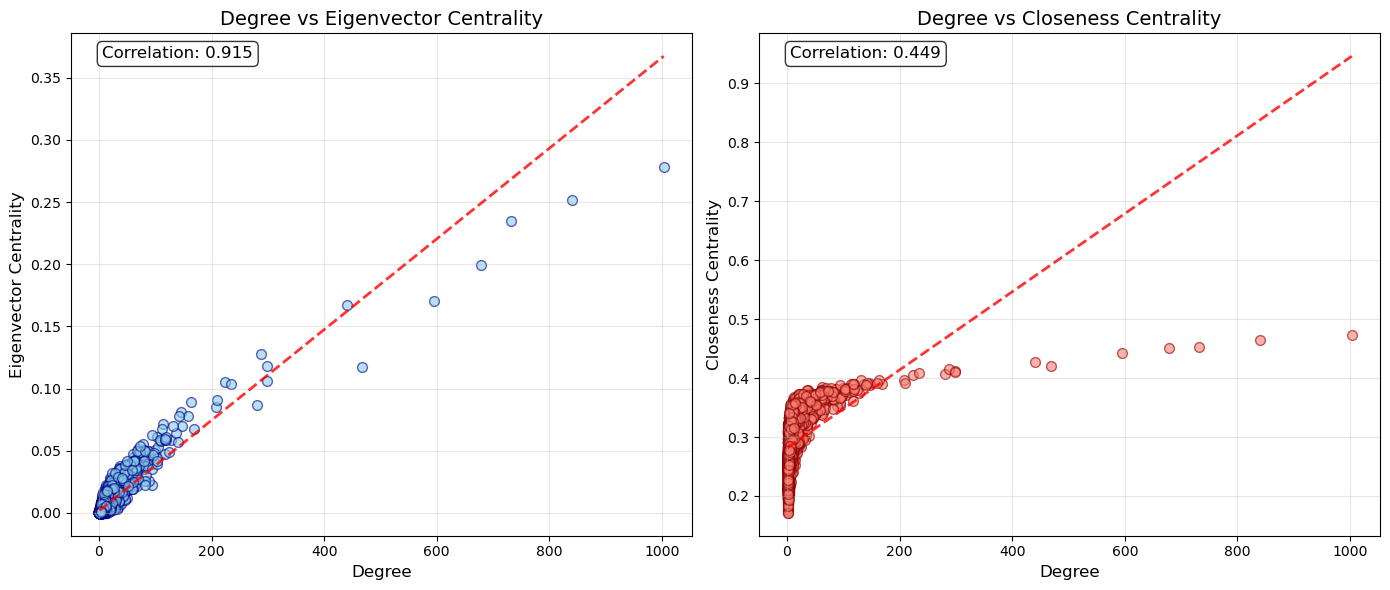

In [11]:
# Plot degree vs centrality values

nodes = list(G_lcc.nodes())
deg_values = [degree_map[node] for node in nodes]
eigen_values = [eigenvector_dict[node] for node in nodes]
close_values = [closeness_dict[node] for node in nodes]

# Create figure
plt.figure(figsize=(14, 6))

# Degree vs Eigenvector
plt.subplot(1, 2, 1)
plt.scatter(deg_values, eigen_values, alpha=0.6, s=50, c='skyblue', edgecolors='navy')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Eigenvector Centrality', fontsize=12)
plt.title('Degree vs Eigenvector Centrality', fontsize=14)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(deg_values, eigen_values, 1)
p = np.poly1d(z)
plt.plot(sorted(deg_values), p(sorted(deg_values)), "r--", alpha=0.8, linewidth=2)

# Calculate correlation
corr = np.corrcoef(deg_values, eigen_values)[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Degree vs Closeness
plt.subplot(1, 2, 2)
plt.scatter(deg_values, close_values, alpha=0.6, s=50, c='salmon', edgecolors='darkred')
plt.xlabel('Degree', fontsize=12)
plt.ylabel('Closeness Centrality', fontsize=12)
plt.title('Degree vs Closeness Centrality', fontsize=14)
plt.grid(True, alpha=0.3)

# Add trend line
z = np.polyfit(deg_values, close_values, 1)
p = np.poly1d(z)
plt.plot(sorted(deg_values), p(sorted(deg_values)), "r--", alpha=0.8, linewidth=2)

# Calculate correlation
corr = np.corrcoef(deg_values, close_values)[0, 1]
plt.text(0.05, 0.95, f'Correlation: {corr:.3f}', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

## 4 — Random network comparison

In [12]:
# Erdos-Renyi random graph with same n and p
def generate_random_network(n, p, seed=None):
    """
    Generate a random network with n nodes where each possible edge
    is included independently with probability p.
    """
    if seed is not None:
        np.random.seed(seed)
    
    G_rand = nx.Graph()
    G_rand.add_nodes_from(range(n)) 
    
    # check every possible pair of nodes
    for i in range(n):
        for j in range(i+1, n):
            if np.random.uniform() < p:
                G_rand.add_edge(i, j)
    
    return G_rand

G_rand = generate_random_network(n=n,p=p_edge,seed = 20)
rand_lcc   = max(nx.connected_components(G_rand), key=len)
SG_rand    = G_rand.subgraph(rand_lcc).copy()
rand_deg   = [d for _, d in G_rand.degree()]
rand_path  = nx.average_shortest_path_length(SG_rand)

print("=== Real vs Random Network ===")
print(f"{'Metric':30s}  {'Real':>10s}  {'Random':>10s}")
print("-" * 55)
print(f"{'Nodes':30s}  {n:>10,}  {G_rand.number_of_nodes():>10,}")
print(f"{'Mean degree':30s}  {mean_deg:>10.2f}  {np.mean(rand_deg):>10.2f}")
print(f"{'Avg shortest path':30s}  {avg_path:>10.4f}  {rand_path:>10.4f}")

=== Real vs Random Network ===
Metric                                Real      Random
-------------------------------------------------------
Nodes                                6,049       6,049
Mean degree                          10.92       10.98
Avg shortest path                   3.5442      3.8879


## 5 — Degree distribution

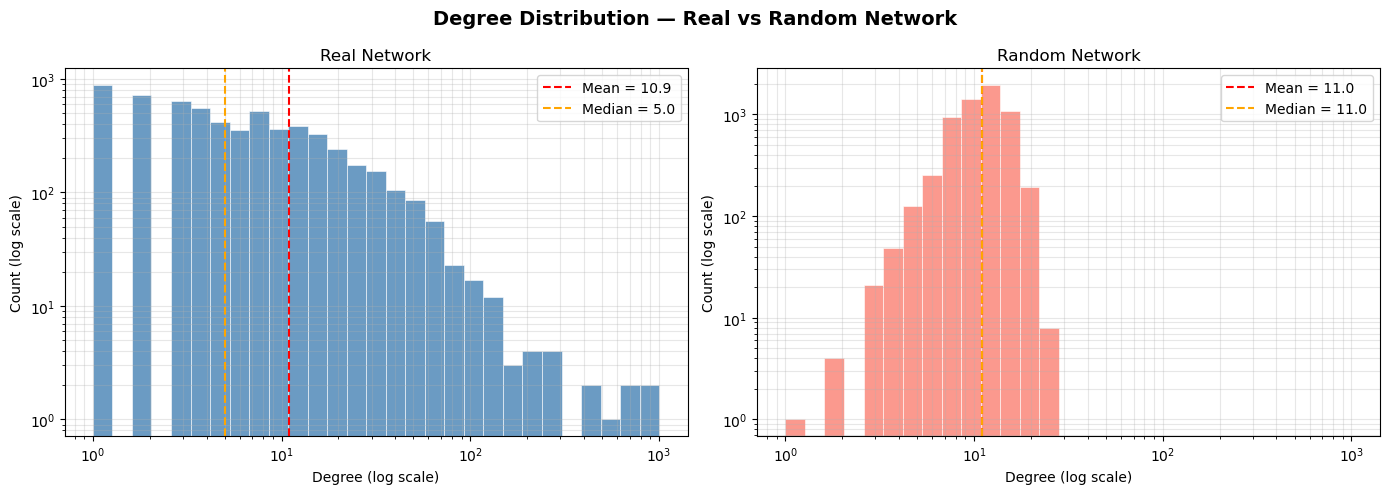

Saved → degree_distribution.png


In [13]:
degrees    = np.array([d for _, d in G_lcc.degree()])
rand_degs  = np.array([d for _, d in SG_rand.degree()])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Degree Distribution — Real vs Random Network", fontsize=14, fontweight="bold")

# Log-spaced bins for both
min_d = max(1, min(degrees.min(), rand_degs.min()))
max_d = max(degrees.max(), rand_degs.max())
bins  = np.logspace(np.log10(min_d), np.log10(max_d), 30)

for ax, data, color, title in [
    (axes[0], degrees,   "steelblue", "Real Network"),
    (axes[1], rand_degs, "salmon",    "Random Network"),
]:
    ax.hist(data, bins=bins, color=color, alpha=0.8,
            edgecolor="white", linewidth=0.5, log=True)
    ax.axvline(np.mean(data), color="red",    linestyle="--", linewidth=1.5,
               label=f"Mean = {np.mean(data):.1f}")
    ax.axvline(np.median(data), color="orange", linestyle="--", linewidth=1.5,
               label=f"Median = {np.median(data):.1f}")
    ax.set_xscale("log")
    ax.set_xlabel("Degree (log scale)"); ax.set_ylabel("Count (log scale)")
    ax.set_title(title); ax.legend(); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.savefig("degree_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → degree_distribution.png")


In [14]:
df["state"].value_counts()

state
Arizona               58
New Jersey            57
Illinois              49
South Carolina        24
Maine                 22
New York City         16
North Carolina        12
Tennessee             11
Indiana               11
Iowa                  10
Mississippi            8
Washington, D.C.       7
South Dakota           7
Rhode Island           5
West Virginia          4
Maryland               2
Los Angeles County     2
Texas                  1
California             1
Austin                 1
Florida                1
Columbia               1
Monroe County          1
New York               1
Name: count, dtype: int64

## 8 — Assortativity

=== Assortativity coefficients ===
  party          : +0.2885  ███████████
  gender         : +0.0977  ███
  is_seed        : +0.1300  █████
  prestigious_school: +0.0066  
  degree         : -0.0848  ███


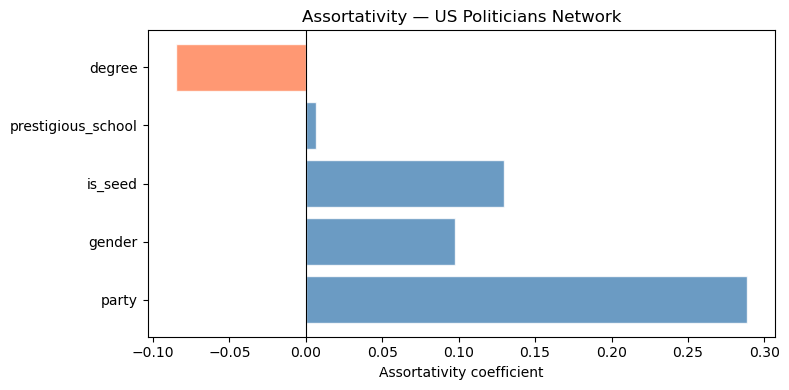

In [15]:
def calculate_assortativity(G, attr):
    mixing  = defaultdict(int)
    

    for u, v in G.edges():
        cu = G.nodes[u][attr]
        cv = G.nodes[v][attr]

        mixing[(cu, cv)] += 1
        mixing[(cv, cu)] += 1

    m = G.number_of_edges()

    for key in mixing:
        mixing[key] /= (2 * m)

    a = defaultdict(float)
    for (i, j), val in mixing.items():
        a[i] += val

    sum_eii = sum(val for (i, j), val in mixing.items() if i == j)
    sum_aibi = sum(a[i] * a[i] for i in a)

    r = (sum_eii - sum_aibi) / (1 - sum_aibi + 1e-7)
    return r

results = {}
for attr in ["party", "gender","is_seed","prestigious_school"]:
    r = calculate_assortativity(G_lcc, attr)
    results[attr] = r
results["degree"] = nx.degree_assortativity_coefficient(G_lcc)

print("=== Assortativity coefficients ===")
for attr, r in results.items():
    bar = "█" * int(abs(r or 0) * 40)
    print(f"  {attr:15s}: {r:+.4f}  {bar}")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
labels = list(results.keys())
values = [v if v is not None else 0 for v in results.values()]
colors = ["steelblue" if v >= 0 else "coral" for v in values]
ax.barh(labels, values, color=colors, alpha=0.8, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Assortativity coefficient")
ax.set_title("Assortativity — US Politicians Network")
plt.tight_layout()
plt.savefig("assortativity.png", dpi=150, bbox_inches="tight")
plt.show()


## 9 — Community detection (Louvain)

Detecting Louvain communities...
Found 35 communities
  Largest community  : 808 nodes
  Smallest community : 3 nodes
  Median size        : 117 nodes

Top 5 communities by size:
party      Democrat  Other  Republican
community                             
15.0            405     40         363
2.0             307     31         359
5.0             272     24         356
30.0            205     12         146
6.0             178     14          67


/var/folders/pt/srr73kjx1pdbnpwylcyp844r0000gn/T/ipykernel_65483/3500357216.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap          = plt.cm.get_cmap("tab20", n_communities)


Found 35 communities
Computing layout for top 2000 nodes by degree…


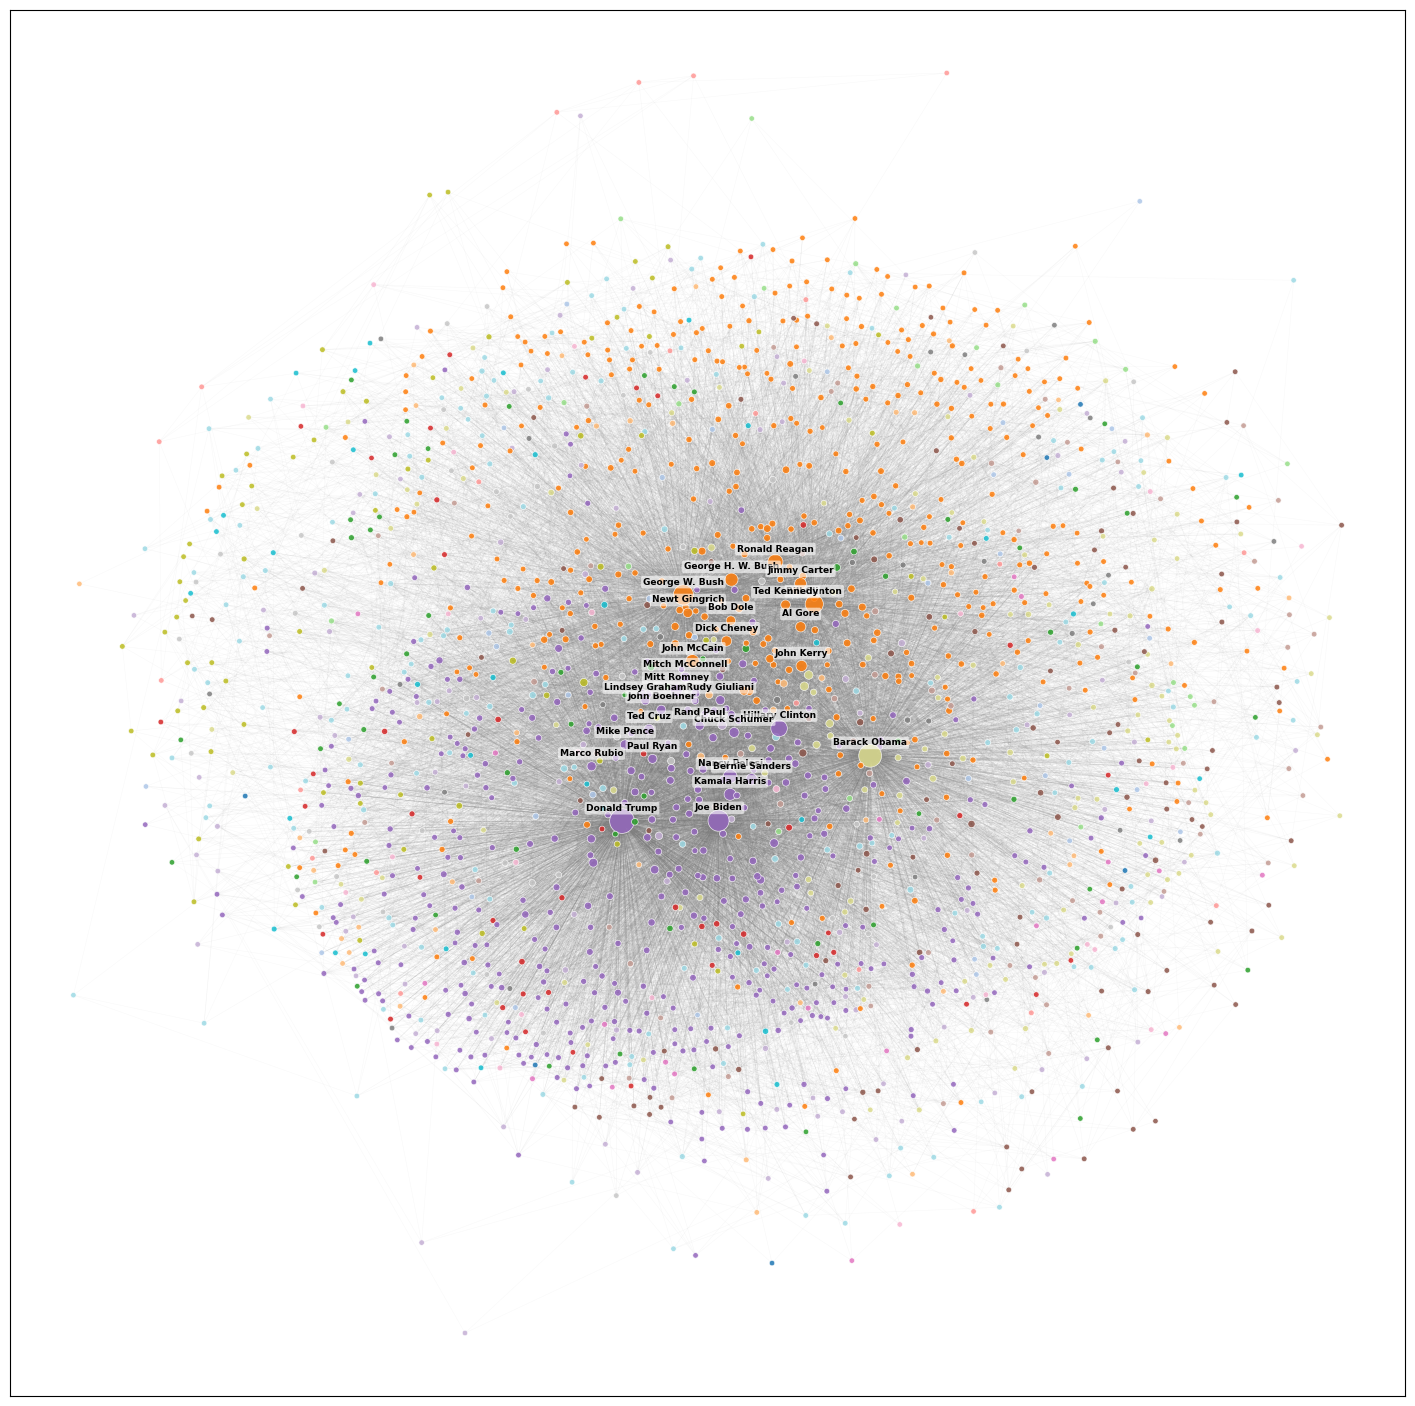

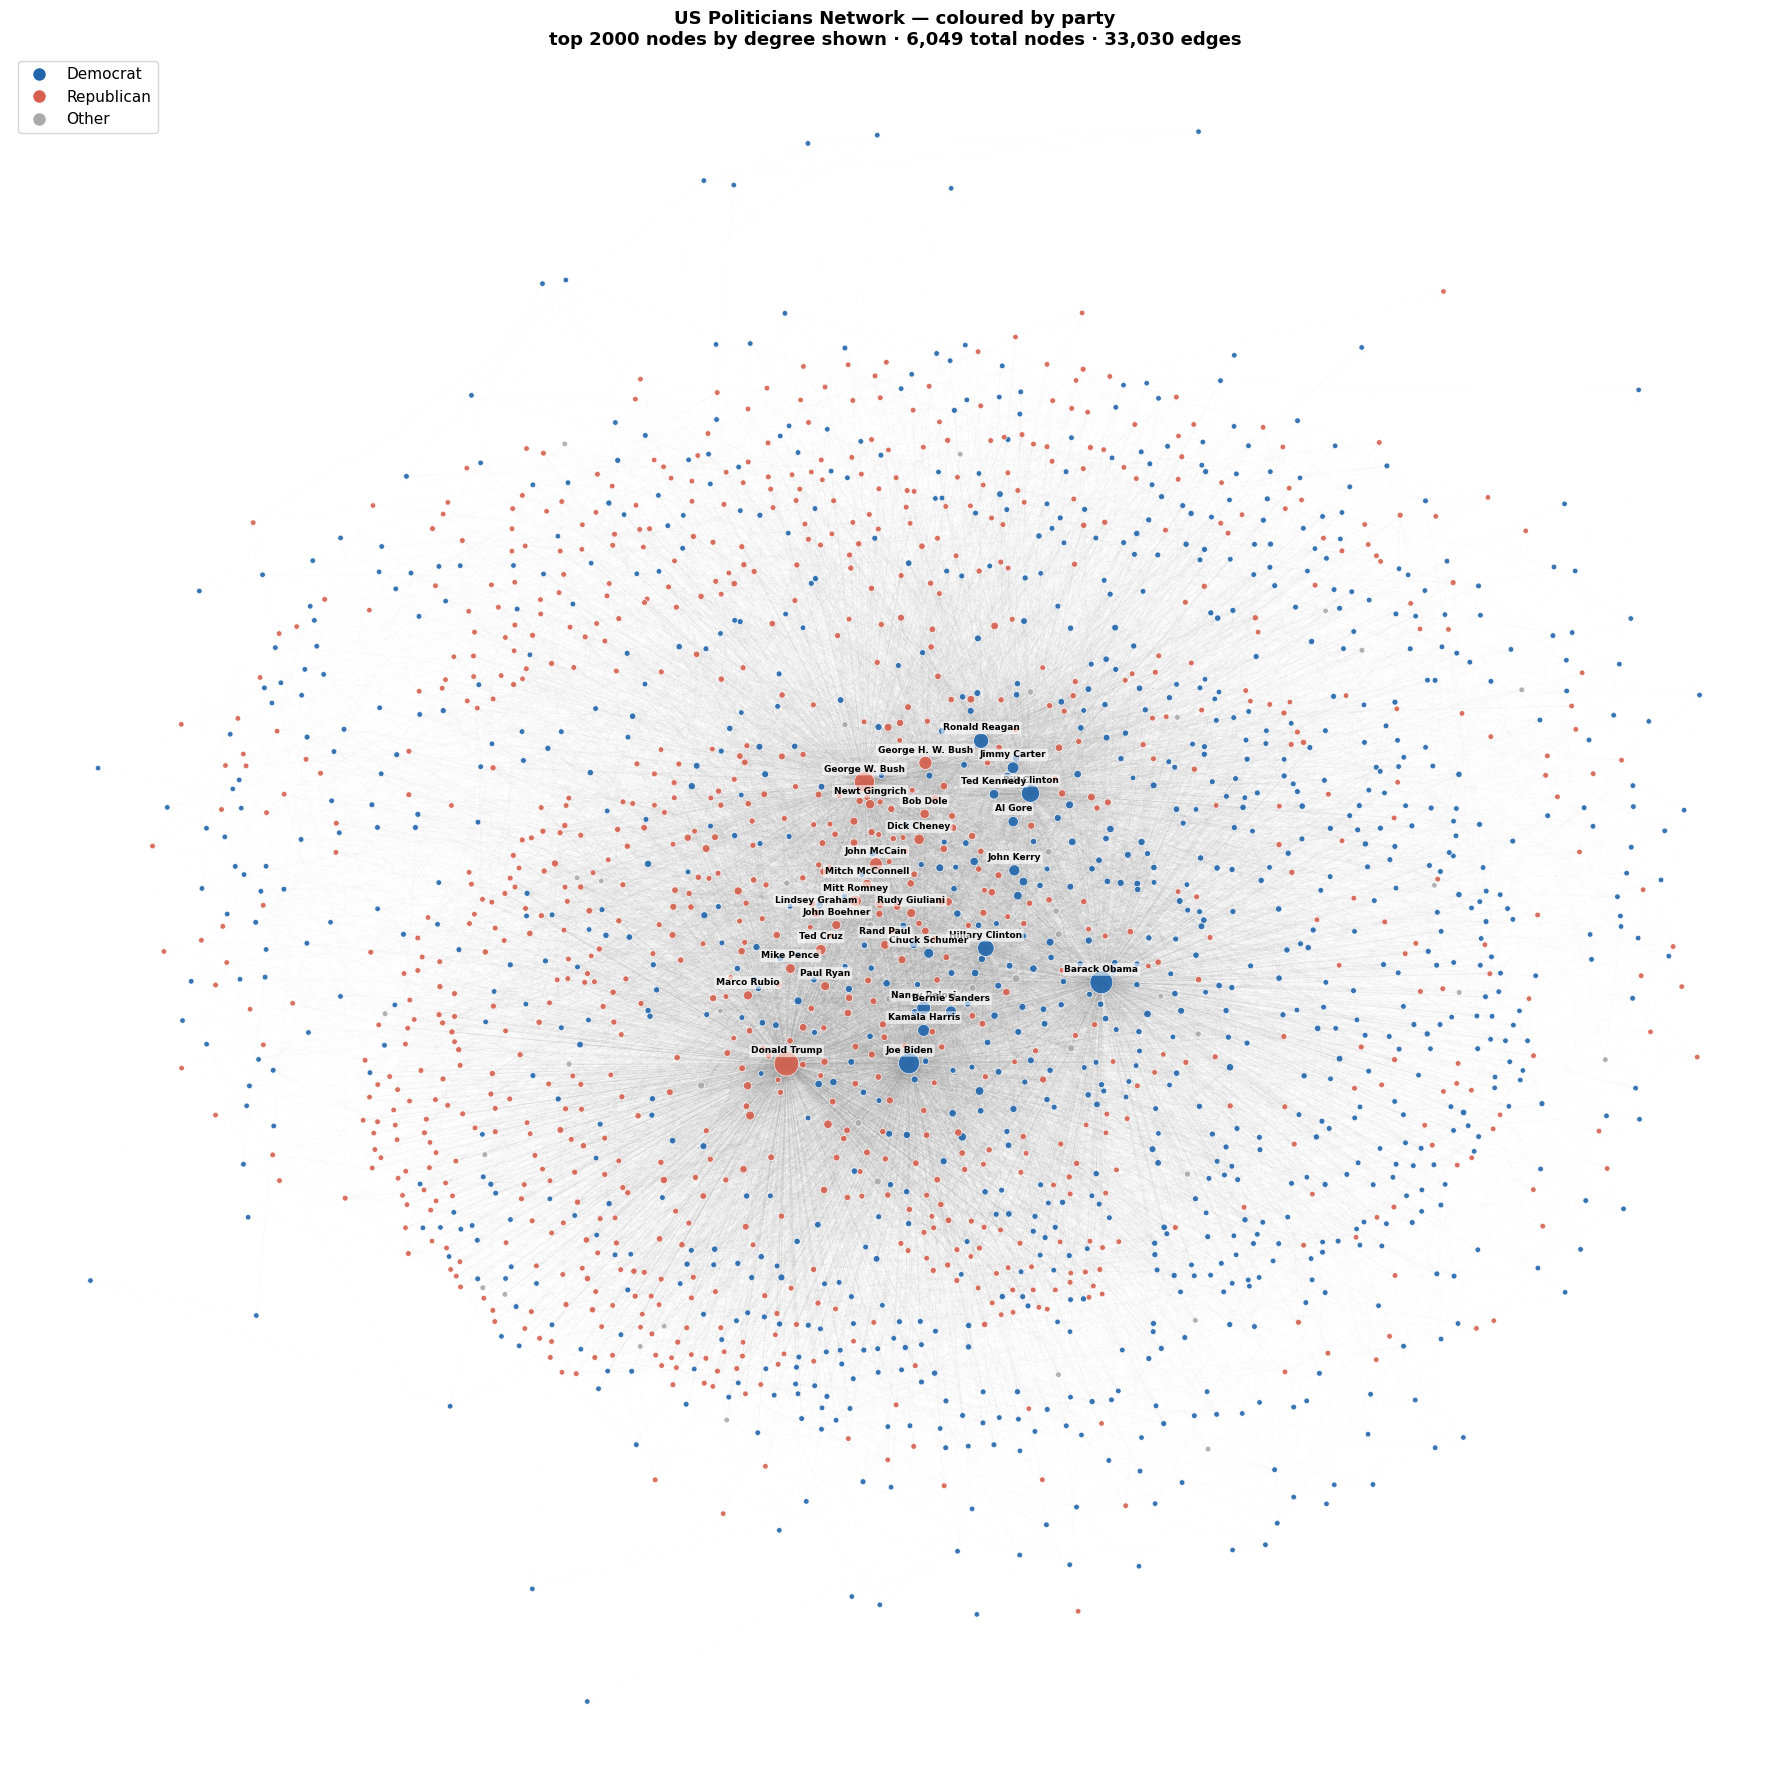

In [16]:
print("Detecting Louvain communities...")
communities = nx.community.louvain_communities(G_lcc, seed=42)
partition   = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i

n_communities = len(communities)
print(f"Found {n_communities} communities")

for n_id in G_lcc.nodes():
    G_lcc.nodes[n_id]["community"] = partition.get(n_id, -1)
df["community"] = df["wikidata"].map(partition)

# Community sizes
sizes = Counter(partition.values())
print(f"  Largest community  : {max(sizes.values())} nodes")
print(f"  Smallest community : {min(sizes.values())} nodes")
print(f"  Median size        : {np.median(list(sizes.values())):.0f} nodes")

# Party composition per community
comm_party = (df.groupby(["community","party"])
                .size()
                .unstack(fill_value=0))
print("\nTop 5 communities by size:")
print(comm_party.loc[comm_party.sum(axis=1).nlargest(5).index])

df.to_csv("politicians_with_communities.csv", index=False)


communities = nx.community.louvain.louvain_communities(G_lcc)
partition = {}
for i, comm in enumerate(communities):
    for node in comm:
        partition[node] = i

# Map community → colour
cmap          = plt.cm.get_cmap("tab20", n_communities)
community_colors = {node: cmap(partition[node]) for node in G_lcc.nodes()}

print(f"Found {n_communities} communities")

# ── Use only top N nodes by degree for a readable plot ────────────────────────
MAX_NODES = 2000
top_nodes  = sorted(G_lcc.nodes(), key=lambda n: G_lcc.degree(n), reverse=True)[:MAX_NODES]
G_display  = G_lcc.subgraph(top_nodes).copy()

print(f"Computing layout for top {MAX_NODES} nodes by degree…")
pos = nx.kamada_kawai_layout(G_display)   # much better structure than spring

# Node properties
node_degrees = [G_display.degree(n) for n in G_display.nodes()]
max_deg      = max(node_degrees)
node_sizes   = [15 + 300 * (d / max_deg) ** 1.2 for d in node_degrees]
node_colors  = [community_colors[n] for n in G_display.nodes()]

# Edge alpha scaled by combined degree of endpoints — prominent edges stand out
edge_weights = []
for u, v in G_display.edges():
    combined = G_display.degree(u) + G_display.degree(v)
    edge_weights.append(combined)
max_w     = max(edge_weights) if edge_weights else 1
edge_alphas = [0.05 + 0.3 * (w / max_w) for w in edge_weights]

fig, ax = plt.subplots(figsize=(18, 18), facecolor="white")

# Draw edges with variable alpha
for (u, v), alpha in zip(G_display.edges(), edge_alphas):
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    ax.plot(x, y, color="gray", alpha=alpha, linewidth=0.4, zorder=1)

# Draw nodes
nx.draw_networkx_nodes(G_display, pos,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.85,
                       linewidths=0.5,
                       edgecolors="white",
                       ax=ax)

# Label top 30 nodes only
top30  = sorted(G_display.nodes(), key=lambda n: G_display.degree(n), reverse=True)[:30]
labels = {n: G_display.nodes[n].get("name", n) for n in top30}
for node, label in labels.items():
    x, y = pos[node]
    ax.annotate(label, (x, y),
                fontsize=6.5, fontweight="bold",
                ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points",
                bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

# ── Second plot: full graph coloured by party ──────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(18, 18), facecolor="white")

PARTY_COLORS = {
    "Democrat":    "#2166ac",
    "Republican":  "#d6604d",
    "Other":       "#aaaaaa",
}

party_node_colors = [
    PARTY_COLORS.get(G_lcc.nodes[n].get("party"), "#dddddd")
    for n in G_display.nodes()
]

for (u, v), alpha in zip(G_display.edges(), edge_alphas):
    x = [pos[u][0], pos[v][0]]
    y = [pos[u][1], pos[v][1]]
    ax2.plot(x, y, color="gray", alpha=alpha * 0.6, linewidth=0.3, zorder=1)

nx.draw_networkx_nodes(G_display, pos,
                       node_color=party_node_colors,
                       node_size=node_sizes,
                       alpha=0.9,
                       linewidths=0.5,
                       edgecolors="white",
                       ax=ax2)

for node, label in labels.items():
    x, y = pos[node]
    ax2.annotate(label, (x, y),
                 fontsize=6.5, fontweight="bold",
                 ha="center", va="bottom",
                 xytext=(0, 6), textcoords="offset points",
                 bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.6, ec="none"))

legend_elements = [
    Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=p)
    for p, c in PARTY_COLORS.items() if p is not None
]
ax2.legend(handles=legend_elements, loc="upper left", fontsize=11, framealpha=0.8)
ax2.set_title(f"US Politicians Network — coloured by party\n"
              f"top {MAX_NODES} nodes by degree shown · "
              f"{G_lcc.number_of_nodes():,} total nodes · {G_lcc.number_of_edges():,} edges",
              fontsize=13, fontweight="bold")
ax2.axis("off")

plt.tight_layout()
fig.savefig("politicians_network_communities.png",  dpi=150, bbox_inches="tight")
fig2.savefig("politicians_network_party.png",       dpi=150, bbox_inches="tight")
plt.show()